In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
from utils2 import read_data, read_dataset

# from utils import read_dataset

train_data, test_data, test_rul = read_dataset("FD001")

In [ ]:
def calculate_RUL(X, upper_threshold=None):
    """
    Calculate Remaining Useful Life per `unit`

    Parameters
    ----------
    X : pd.DataFrame, with `unit` and `time_cycles` columns
    upper_threshold: int, limit maximum RUL valus, default is None

    Returns
    -------
    np.array with Remaining Useful Life values
    """
    lifetime = X.groupby(["unit"])["time_cycles"].transform(max)
    rul = lifetime - X["time_cycles"]

    if upper_threshold:
        rul = np.where(rul > upper_threshold, upper_threshold, rul)

    return rul

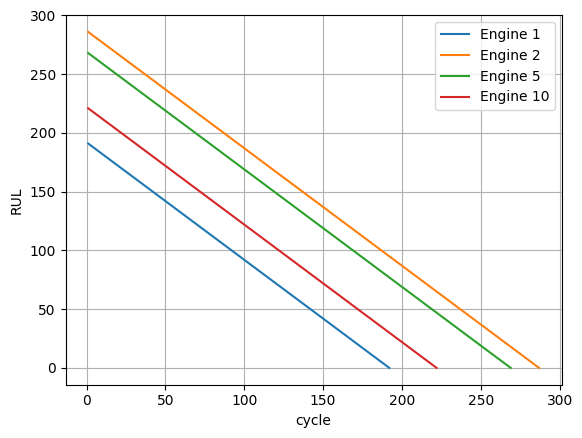

In [15]:
train_data["rul"] = calculate_RUL(train_data)

for _unit in [1, 2, 5, 10]:
    plt.plot(
        train_data[train_data["unit"] == _unit]["time_cycles"],
        train_data[train_data["unit"] == _unit]["rul"],
        label=f"Engine {_unit}",
    )
plt.legend()
plt.xlabel("cycle")
plt.ylabel("RUL")
plt.grid()
plt.show()

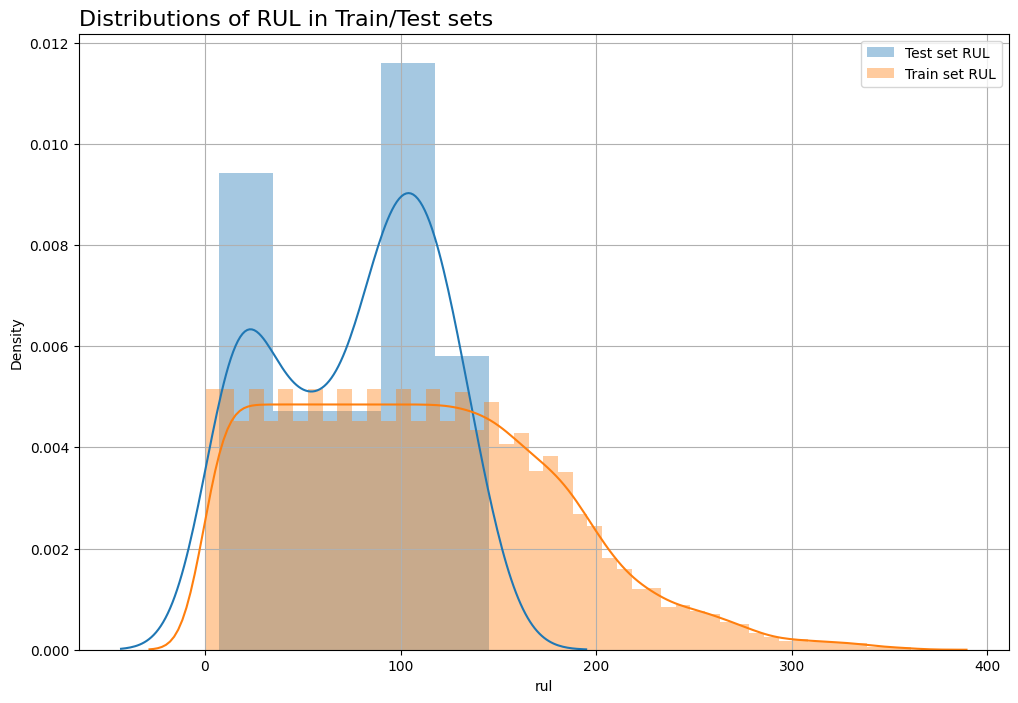

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_title("Distributions of RUL in Train/Test sets", loc="left", size=16)
sns.distplot(test_rul, label="Test set RUL")
sns.distplot(train_data["rul"], label="Train set RUL")
ax.legend()
ax.grid()
plt.show()

### As you can see from the figure above, the Train set contains samples with RUL way higher than in the Test set and this is because there're engines full lifetime data in the Train set, and in the Test set there's engines data till some period of time before its end of life.

In most of the papers related to this problem, maximum value of RUL is being limited to some constant value. And the motivation is that a degradatation process will be only noticeable in the data after a unit has operated for some time. You can read more about this in this paper - https://www.researchgate.net/publication/224358896_Recurrent_neural_networks_for_remaining_useful_life_estimation.

So, we are going to limit a maximum value of RUL with 125 (you can find details about how this specific value was picked in the paper following the link above) - please, see the changed RUL plots below:

In [18]:
RUL_UPPER_THRESHOLD = 125

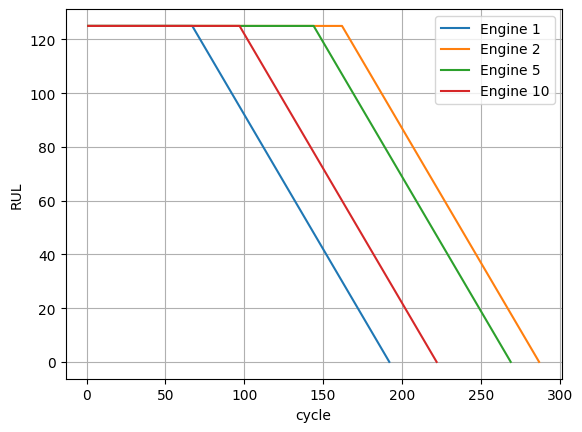

In [19]:
train_data["rul"] = calculate_RUL(train_data, upper_threshold=RUL_UPPER_THRESHOLD)

for _unit in [1, 2, 5, 10]:
    plt.plot(
        train_data[train_data["unit"] == _unit]["time_cycles"],
        train_data[train_data["unit"] == _unit]["rul"],
        label=f"Engine {_unit}",
    )
plt.legend()
plt.xlabel("cycle")
plt.ylabel("RUL")
plt.grid()
plt.show()

train_data = train_data.drop(columns=["rul"])